In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('Walmart_Sales.csv')  # adjust path if needed
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [5]:
df.isna().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [6]:
scaler = StandardScaler()

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

X = df.drop(columns=['Weekly_Sales', 'Date'])
y = df['Weekly_Sales'].values.reshape(-1, 1)

# Scale the features (X) and the target variable (y)
y_scaled = scaler.fit_transform(y)
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

In [7]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

Text(0.5, 1.0, 'Elbow Method')

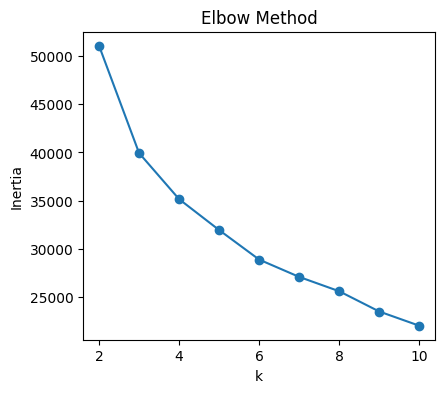

In [8]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')

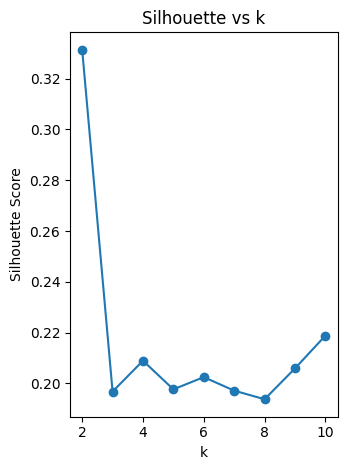

In [9]:
plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette Score'); plt.title('Silhouette vs k')
plt.tight_layout()
plt.show()

In [10]:
best_k = 3  # for example, after inspecting plots
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled)
df['Cluster_KMeans'] = kmeans_labels

In [11]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
df['Cluster_Agg'] = agg_labels

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

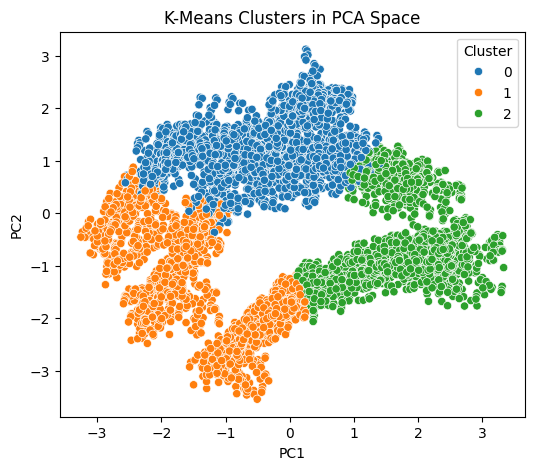

In [13]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster_KMeans', palette='tab10')
plt.title('K-Means Clusters in PCA Space')
plt.legend(title='Cluster')
plt.show()

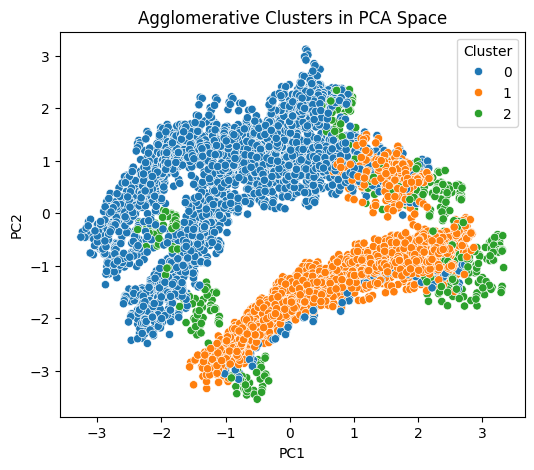

In [14]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster_Agg', palette='tab10')
plt.title('Agglomerative Clusters in PCA Space')
plt.legend(title='Cluster')
plt.show()

In [15]:
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.24680666 0.19839471]


In [16]:
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
sil_agg = silhouette_score(X_scaled, agg_labels)

print("Silhouette (K-Means):", sil_kmeans)
print("Silhouette (Agglomerative):", sil_agg)

Silhouette (K-Means): 0.19672018254022788
Silhouette (Agglomerative): 0.1907770814578886


In [17]:
cluster_summary_kmeans = df.groupby('Cluster_KMeans')[['Weekly_Sales','Holiday_Flag',
                                                       'Temperature','Fuel_Price','CPI',
                                                       'Unemployment']].mean()
display(cluster_summary_kmeans)
print()
cluster_summary_agg = df.groupby('Cluster_Agg')[['Weekly_Sales','Holiday_Flag',
                                                 'Temperature','Fuel_Price','CPI',
                                                 'Unemployment']].mean()
display(cluster_summary_agg)

,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Cluster_KMeans,,,,,,
0,1.036301e+06,0.020841,71.675164,3.768712,174.210057,7.655422
1,1.006518e+06,0.076314,43.935664,3.179409,167.876101,8.167634
2,1.094762e+06,0.125783,61.175373,2.999290,171.448619,8.284720


,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Cluster_Agg,,,,,,
0,1.022023e+06,0.0,62.808139,3.632659,172.581738,7.970182
1,1.075316e+06,0.0,59.039764,2.900628,169.866284,8.034830
2,1.122888e+06,1.0,50.232044,3.227464,171.268092,8.074127
